## EDA Notebook
This notebook will contain the eda process of all the raw csv files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from pathlib import Path

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",50)
pd.set_option("display.float_format","{:.2f}".format)

In [3]:
# Setting paths for easier navigation
RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

In [4]:
# Plot Style
sns.set_theme(style="darkgrid",palette="muted")
COLORS = {"Fatal": "#e74c3c", "Serious": "#e67e22", "Minor": "#3498db"}

### Loading the datasets

In [5]:
# India mendeley - data/raw/crashes/csv
mendeley_path = RAW / "india_mendeley" / "crashes.csv"
df_mendeley = pd.read_csv(mendeley_path)
print(f"df_mendeley shape - {df_mendeley.shape}")
df_mendeley.head(3)

df_mendeley shape - (2898, 17)


,S. No.,Month,Crash Date,Crash Day,Article Date,Location,Million Plus City,State,LatLong,Vehicle 1,Vehicle/Object 2,Killed,Injured,Age,Gender,Road Type,Crash Type
0,1,January,44561,Friday,44562,Alni,Nil,Maharashtra,"18.278457450374876, 76.00957388786227",Car,Tractor,4,0,"70,50,45,23",Both,NH,Head On Collision
1,2,January,44561,Friday,44562,Hariharganj,Nil,Jharkhand,"24.543681356839087, 84.28057070288547",Pick Up,Truck,6,18,NaN,Both,NH,Head On Collision
2,3,January,44560,Thursday,44562,Dabolim,Nil,Goa,"15.390068035586195, 73.85497360324335",Car,Divider,3,2,"27,24,24",Male,NH,Fixed Object Collision


In [6]:
# Kaggle india accidents
kaggle_path = RAW / "kaggle_india" / "accident_prediction_india.csv"
df_kaggle = pd.read_csv(kaggle_path)
print(f"india road accidents shape - {df_kaggle.shape}")
df_kaggle.head(3)

india road accidents shape - (3000, 22)


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,Number of Fatalities,Weather Conditions,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,4,Hazy,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,4,Hazy,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,5,Foggy,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge


In [7]:
global_path = RAW / "global" / "Global Road Accidents Dataset.csv"
df_global = pd.read_csv(global_path, low_memory=False)
print(f"Global accident shape - {df_global.shape}")
print(f"Columns: {list(df_global.columns)}")
# print()
# print(" Global Kaggle has NO latitude/longitude columns.")
# print("   It is used ONLY for feature pattern learning.")
# print("   Columns useful for ML:", [
#     'Country','Road Type','Weather Conditions','Speed Limit',
#     'Accident Severity','Number of Injuries','Number of Fatalities',
#     'Road Condition','Accident Cause','Urban/Rural'
# ])
df_global.head(3)

Global accident shape - (132000, 30)
Columns: ['Country', 'Year', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural', 'Road Type', 'Weather Conditions', 'Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Age Group', 'Driver Gender', 'Driver Alcohol Level', 'Driver Fatigue', 'Vehicle Condition', 'Pedestrians Involved', 'Cyclists Involved', 'Accident Severity', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Road Condition', 'Accident Cause', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Region', 'Population Density']


,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,Speed Limit,Driver Age Group,Driver Gender,Driver Alcohol Level,Driver Fatigue,Vehicle Condition,Pedestrians Involved,Cyclists Involved,Accident Severity,Number of Injuries,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,220.41,1,37,18-25,Male,0.05,0,Poor,1,2,Moderate,8,2,58.63,7412.75,Wet,Weather,4,40499.86,22072.88,Europe,3866.27
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.31,3,96,18-25,Female,0.23,1,Poor,1,1,Minor,6,1,58.04,4458.63,Snow-covered,Mechanical Failure,3,6486.60,9534.40,North America,2333.92
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.29,4,62,41-60,Male,0.14,0,Moderate,0,0,Moderate,13,4,42.37,9856.92,Wet,Speeding,4,29164.41,58009.15,South America,4408.89


In [8]:
# MoRTH files
morth_dir = RAW / "morth"

df_sw_acc  = pd.read_csv(morth_dir / "statewise_accidents_2019_2023.csv")
df_sw_fat  = pd.read_csv(morth_dir / "statewise_fatalities_2019_2023.csv")
df_collide = pd.read_csv(morth_dir / "collision_types_2023.csv")
df_violate = pd.read_csv(morth_dir / "violation_types_2023.csv")
df_cities  = pd.read_csv(morth_dir / "large_cities_2023.csv")

print(f"  statewise_accidents   → {df_sw_acc.shape}")
print(f"  statewise_fatalities  → {df_sw_fat.shape}")
print(f"  collision_types       → {df_collide.shape}")
print(f"  violation_types       → {df_violate.shape}")
print(f"  large_cities          → {df_cities.shape}")

  statewise_accidents   → (40, 14)
  statewise_fatalities  → (40, 13)
  collision_types       → (19, 10)
  violation_types       → (13, 10)
  large_cities          → (51, 14)


### Data Quality Audit

In [9]:
def audit(df, name):
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f"  Shape      : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"  Duplicates : {df.duplicated().sum():,}")
    print(f"  Dtypes     :\n{df.dtypes.value_counts().to_string()}")
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f"  Missing values:")
        for col, cnt in miss.items():
            print(f"    {col:<35} {cnt:>5} ({cnt/len(df)*100:.1f}%)")
    else:
        print("  Missing values : None")

audit(df_mendeley, "India Mendeley  (HAS LatLong)")


 India Mendeley  (HAS LatLong)
  Shape      : 2,898 rows × 17 cols
  Duplicates : 0
  Dtypes     :
str      13
int64     4
  Missing values:
    Age                                   728 (25.1%)
    Gender                                263 (9.1%)


In [10]:
audit(df_kaggle,   "Kaggle India (NO coords — State+City only)")


 Kaggle India (NO coords — State+City only)
  Shape      : 3,000 rows × 22 cols
  Duplicates : 0
  Dtypes     :
str      16
int64     6
  Missing values:
    Traffic Control Presence              716 (23.9%)
    Driver License Status                 975 (32.5%)


In [11]:
audit(df_global,   "Global Kaggle (NO coords — feature data only)")


 Global Kaggle (NO coords — feature data only)
  Shape      : 132,000 rows × 30 cols
  Duplicates : 0
  Dtypes     :
str        14
int64       9
float64     7
  Missing values : None


In [12]:
# Column overview for each dataset
def column_overview(data_name, data_given):
    print(f"\n— {data_name} columns")
    print("-" * 30)

    for col in data_given.columns:
        dtype = str(data_given[col].dtype)
        nuniq = data_given[col].nunique()
        sample = str(data_given[col].dropna().iloc[0])[:40] if len(data_given[col].dropna()) > 0 else "N/A"

        print(f"{col:<40} {dtype:<10} {nuniq:>6} unique | e.g. {sample}")

column_overview("Mendeley", df_mendeley)


— Mendeley columns
------------------------------
S. No.                                   int64        2898 unique | e.g. 1
Month                                    str            12 unique | e.g. January
Crash Date                               str           698 unique | e.g. 44561
Crash Day                                str             7 unique | e.g. Friday
Article Date                             int64         728 unique | e.g. 44562
Location                                 str          2725 unique | e.g. Alni
Million Plus City                        str            43 unique | e.g. Nil
State                                    str            30 unique | e.g. Maharashtra
LatLong                                  str          2898 unique | e.g. 18.278457450374876, 76.00957388786227
Vehicle 1                                str            17 unique | e.g. Car
Vehicle/Object 2                         str            39 unique | e.g. Tractor
Killed                                   int64

In [13]:
column_overview("Kaggle India", df_kaggle)


— Kaggle India columns
------------------------------
State Name                               str            32 unique | e.g. Jammu and Kashmir
City Name                                str            28 unique | e.g. Unknown
Year                                     int64           6 unique | e.g. 2021
Month                                    str            12 unique | e.g. May
Day of Week                              str             7 unique | e.g. Monday
Time of Day                              str          1263 unique | e.g. 1:46
Accident Severity                        str             3 unique | e.g. Serious
Number of Vehicles Involved              int64           5 unique | e.g. 5
Vehicle Type Involved                    str             7 unique | e.g. Cycle
Number of Casualties                     int64          11 unique | e.g. 0
Number of Fatalities                     int64           6 unique | e.g. 4
Weather Conditions                       str             5 unique | e.g. Ha

In [14]:
column_overview("Global", df_global)


— Global columns
------------------------------
Country                                  str            10 unique | e.g. USA
Year                                     int64          25 unique | e.g. 2002
Month                                    str            12 unique | e.g. October
Day of Week                              str             7 unique | e.g. Tuesday
Time of Day                              str             4 unique | e.g. Evening
Urban/Rural                              str             2 unique | e.g. Rural
Road Type                                str             3 unique | e.g. Street
Weather Conditions                       str             5 unique | e.g. Windy
Visibility Level                         float64    132000 unique | e.g. 220.4146505416504
Number of Vehicles Involved              int64           4 unique | e.g. 1
Speed Limit                              int64          90 unique | e.g. 37
Driver Age Group                         str             5 unique | e.g. 

### Mendeley Dataset
This is primary spatial dataset.

In [15]:
print("Mendeley — State distribution:")
print(df_mendeley["State"].value_counts().to_string())

Mendeley — State distribution:
State
Maharashtra         428
Uttar Pradesh       324
Madhya Pradesh      282
Tamil Nadu          225
Karnataka           190
Rajasthan           188
Andhra Pradesh      167
Telangana           114
Punjab              104
Haryana              96
West Bengal          95
Gujarat              93
Delhi                77
Uttarakhand          75
Kerala               74
Chhattisgarh         74
Bihar                54
Jammu                40
Himachal Pradesh     38
Assam                37
Goa                  34
Jharkhand            32
Odisha               28
Chandigarh           16
Nagaland              3
Chhatisgarh           2
Mizoram               2
Manipur               2
Sikkim                2
Meghalaya             2


In [16]:
# Parse lat/lng from LatLong column
coords = df_mendeley["LatLong"].str.split(",", expand=True)
df_mendeley["latitude"]  = pd.to_numeric(coords[0].str.strip(), errors="coerce")
df_mendeley["longitude"] = pd.to_numeric(coords[1].str.strip(), errors="coerce")

print(f"Lat range : {df_mendeley['latitude'].min():.4f} → {df_mendeley['latitude'].max():.4f}")
print(f"Lng range : {df_mendeley['longitude'].min():.4f} → {df_mendeley['longitude'].max():.4f}")
print(f"Valid coords: {df_mendeley[['latitude','longitude']].notna().all(axis=1).sum()} / {len(df_mendeley)}")

Lat range : 8.3019 → 34.9009
Lng range : 69.6542 → 95.7674
Valid coords: 2898 / 2898


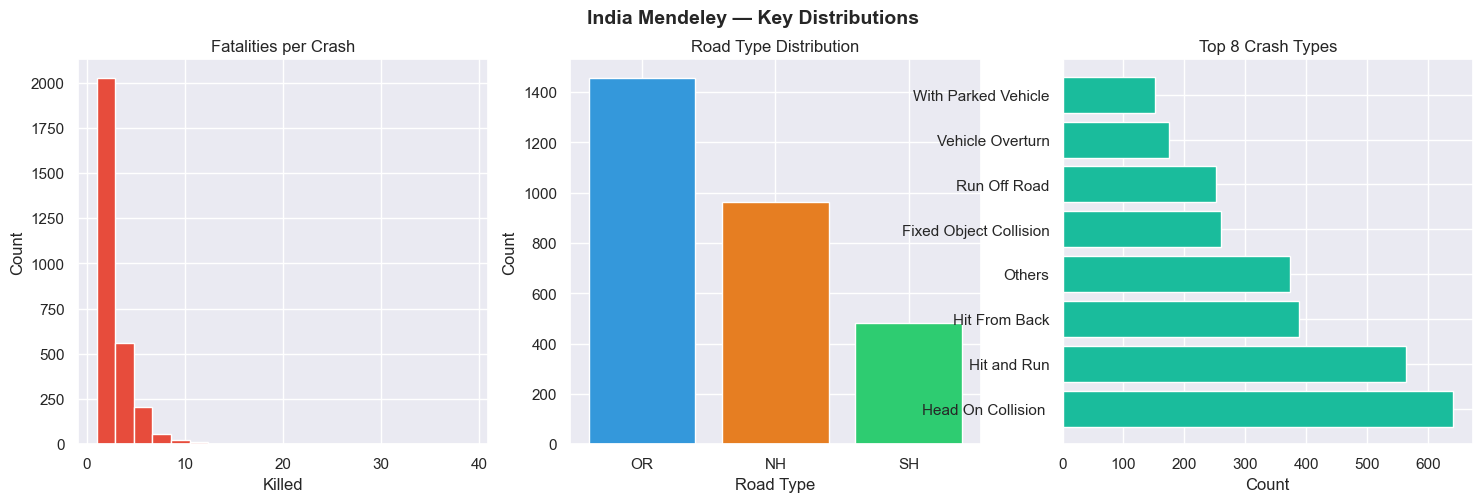

Plot saved to data/processed.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("India Mendeley — Key Distributions", fontsize=14, fontweight="bold")

# Killed distribution
axes[0].hist(df_mendeley["Killed"].dropna(), bins=20, color="#e74c3c", edgecolor="white")
axes[0].set_title("Fatalities per Crash")
axes[0].set_xlabel("Killed")
axes[0].set_ylabel("Count")

# Road type
rt = df_mendeley["Road Type"].value_counts()
axes[1].bar(rt.index, rt.values, color=["#3498db","#e67e22","#2ecc71","#9b59b6"])
axes[1].set_title("Road Type Distribution")
axes[1].set_xlabel("Road Type")
axes[1].set_ylabel("Count")

# Crash type
ct = df_mendeley["Crash Type"].value_counts().head(8)
axes[2].barh(ct.index, ct.values, color="#1abc9c")
axes[2].set_title("Top 8 Crash Types")
axes[2].set_xlabel("Count")

# plt.tight_layout()
plt.savefig(PROCESSED / "eda_mendeley_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to data/processed.")

**A very important thing can be noticed here:**
The histogram shows that most crashes result in 1–2 fatalities, indicating low-severity incidents are most common.
As fatalities increase, the number of crashes drops sharply.
The distribution is right-skewed, with a long tail toward higher fatality values.
A few rare crashes involve very high deaths, acting as outliers.
These extreme cases, though uncommon, contribute significantly to overall fatalities.

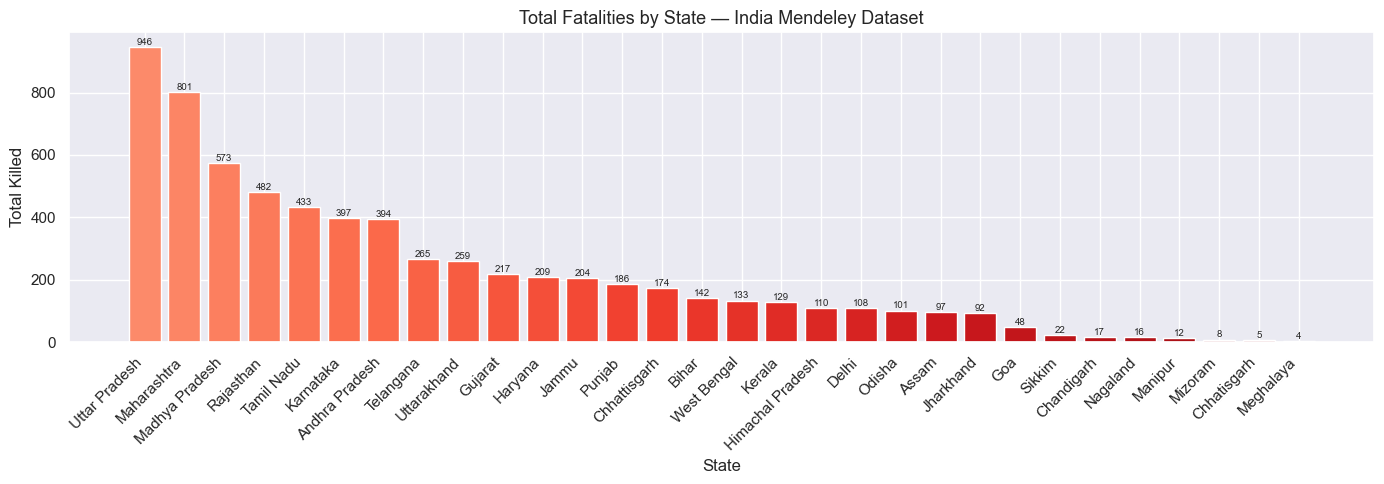

In [18]:
# Top states by fatalities
state_fatal = df_mendeley.groupby("State")["Killed"].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
bars = plt.bar(state_fatal.index, state_fatal.values, color=plt.cm.Reds(
    np.linspace(0.4, 0.9, len(state_fatal))))
plt.title("Total Fatalities by State — India Mendeley Dataset", fontsize=13)
plt.xlabel("State")
plt.ylabel("Total Killed")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, state_fatal.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(int(val)), ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(PROCESSED / "eda_mendeley_state_fatalities.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
# monthyly trend
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
if "Month" in df_mendeley.columns:
    monthly = df_mendeley.groupby("Month")["Killed"].sum()
    monthly = monthly.reindex([m for m in month_order if m in monthly.index])
    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly.values, marker="o",
             color="#e74c3c", linewidth=2.5)
    plt.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color="#e74c3c")
    plt.xticks(range(len(monthly)), monthly.index, rotation=30)
    plt.title("Monthly Fatality Trend — Mendeley", fontsize=13)
    plt.xlabel("Month")
    plt.ylabel("Total Killed")
    plt.tight_layout()
    plt.savefig(PROCESSED / "eda_mendeley_monthly.png", dpi=120)
    plt.show()

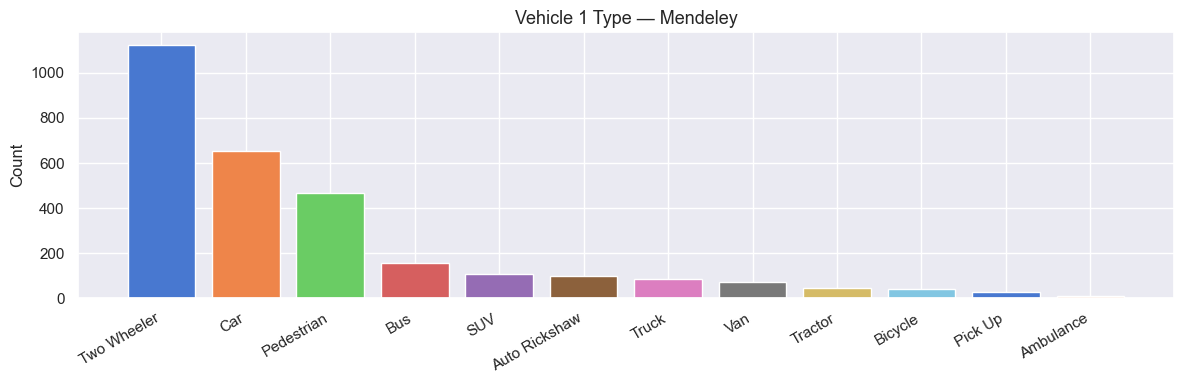

In [20]:
# Vehicle types
if "Vehicle 1" in df_mendeley.columns:
    v1 = df_mendeley["Vehicle 1"].value_counts().head(12)
    plt.figure(figsize=(12, 4))
    plt.bar(v1.index, v1.values, color=sns.color_palette("muted", len(v1)))
    plt.title("Vehicle 1 Type — Mendeley", fontsize=13)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(PROCESSED / "eda_mendeley_vehicles.png", dpi=120)
    plt.show()

### India accident data set kaggle

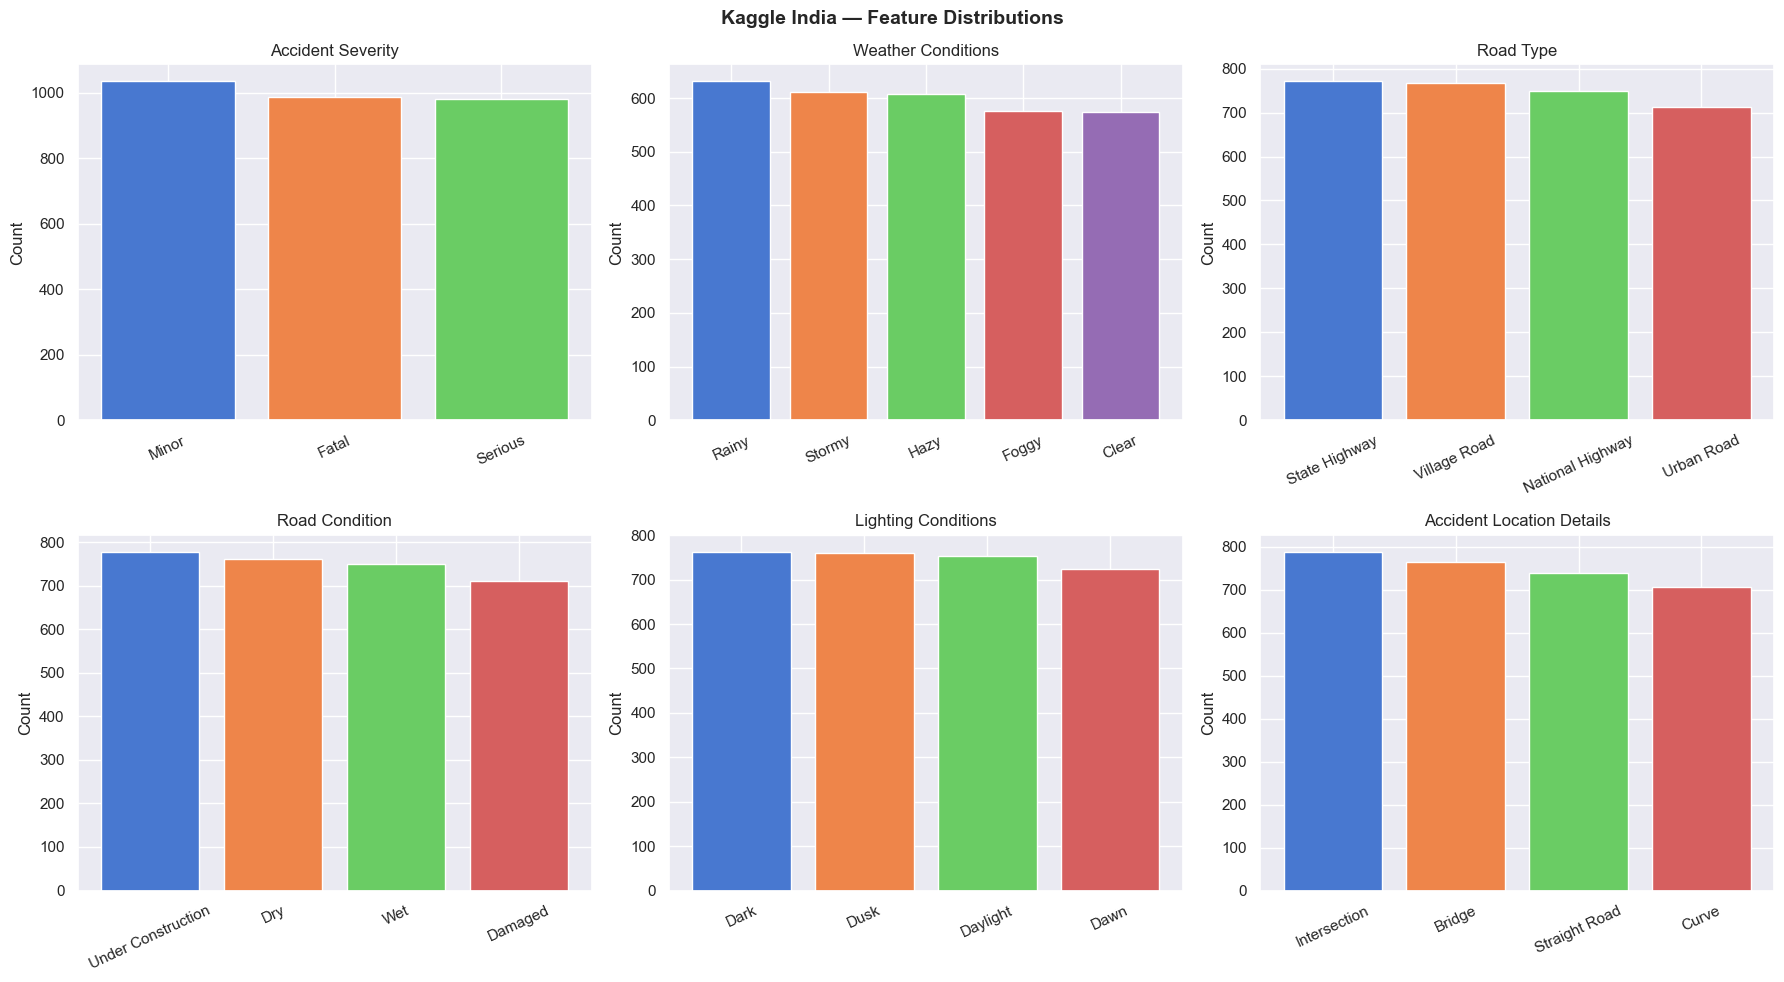

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Kaggle India — Feature Distributions", fontsize=14, fontweight="bold")

cols_cat = ["Accident Severity","Weather Conditions","Road Type",
            "Road Condition","Lighting Conditions","Accident Location Details"]

for ax, col in zip(axes.flat, cols_cat):
    vc = df_kaggle[col].value_counts()
    ax.bar(vc.index, vc.values, color=sns.color_palette("muted", len(vc)))
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(PROCESSED / "eda_kaggle_features.png", dpi=120, bbox_inches="tight")
plt.show()

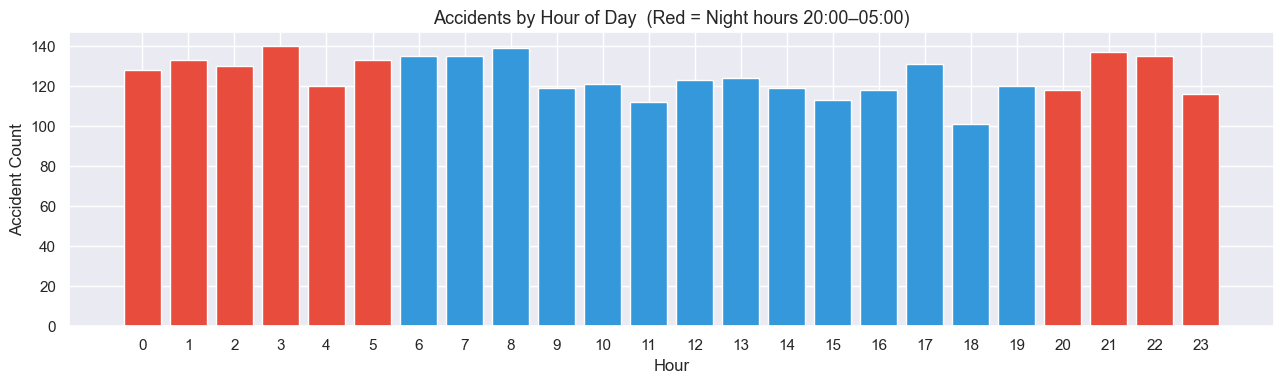

In [32]:
# Time of day → extract hour
df_kaggle["hour"] = pd.to_datetime(df_kaggle["Time of Day"],
                                    format="%H:%M", errors="coerce").dt.hour

hourly = df_kaggle.groupby("hour").size()

plt.figure(figsize=(13, 4))
plt.bar(hourly.index, hourly.values,
        color=["#e74c3c" if (h >= 20 or h <= 5) else "#3498db" for h in hourly.index])
plt.title("Accidents by Hour of Day  (Red = Night hours 20:00–05:00)", fontsize=13)
plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(PROCESSED / "eda_kaggle_hourly.png", dpi=120)
plt.show()

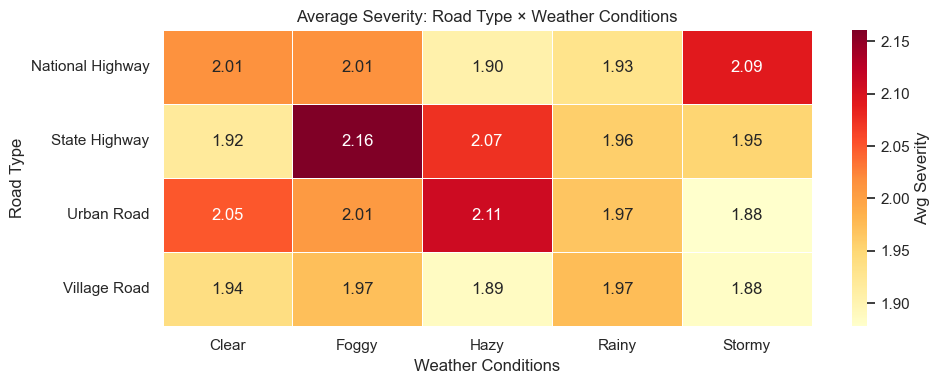

In [22]:
# Severity vs features heatmap
sev_map = {"Minor": 1, "Serious": 2, "Fatal": 3}
df_kaggle["severity_num"] = df_kaggle["Accident Severity"].map(sev_map)

pivot = df_kaggle.pivot_table(
    values="severity_num",
    index="Road Type",
    columns="Weather Conditions",
    aggfunc="mean"
)

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Avg Severity"})
plt.title("Average Severity: Road Type × Weather Conditions", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED / "eda_severity_heatmap.png", dpi=120)
plt.show()

In [24]:
# City coverage
city_counts = df_kaggle["City Name"].value_counts()
unknown_pct = (df_kaggle["City Name"]=="Unknown").sum() / len(df_kaggle) * 100
known_cities = df_kaggle[df_kaggle["City Name"]!="Unknown"]["City Name"].unique()

print(f"City Name coverage:")
print(f"  Total rows           : {len(df_kaggle):,}")
print(f"  Unknown city rows    : {(df_kaggle['City Name']=='Unknown').sum():,}"
      f" ({unknown_pct:.1f}%) → will use state capital coords")
print(f"  Named city rows      : {(df_kaggle['City Name']!='Unknown').sum():,}"
      f" ({100-unknown_pct:.1f}%) → will use city coords")
print(f"  Unique named cities  : {len(known_cities)}")
print(f"  Named cities         : {sorted(known_cities)}")
print()
print("Geocoding plan:")
print(" Named cities → static CITY_COORDS dict (no API)")
print(" Unknown    → STATE_CAPITALS dict + ±0.3° jitter")

City Name coverage:
  Total rows           : 3,000
  Unknown city rows    : 2,138 (71.3%) → will use state capital coords
  Named city rows      : 862 (28.7%) → will use city coords
  Unique named cities  : 27
  Named cities         : ['Ahmedabad', 'Bangalore', 'Chennai', 'Coimbatore', 'Durgapur', 'Dwarka', 'Jaipur', 'Jodhpur', 'Kanpur', 'Kolkata', 'Lucknow', 'Madurai', 'Mangalore', 'Mumbai', 'Mysore', 'Nagpur', 'New Delhi', 'Pune', 'Rohini', 'Siliguri', 'Surat', 'Tirupati', 'Udaipur', 'Vadodara', 'Varanasi', 'Vijayawada', 'Visakhapatnam']

Geocoding plan:
 Named cities → static CITY_COORDS dict (no API)
 Unknown    → STATE_CAPITALS dict + ±0.3° jitter


### Global Kaggle Dataset
*132,000 rows. NO coordinates. Used ONLY for feature pattern learning.*
*Do NOT attempt to cluster or spatially map this dataset.*

In [26]:
print("Global Kaggle — exact column names (NO lat/lng):")
for col in df_global.columns:
    nuniq = df_global[col].nunique()
    sample_vals = df_global[col].dropna().unique()[:3]
    print(f"  {col:<40} {nuniq:>6} unique | e.g. {list(sample_vals)}")
print()
print("Confirming: 'latitude' in columns:", 'latitude' in df_global.columns)
print("Confirming: 'longitude' in columns:", 'longitude' in df_global.columns)
print("Confirming: 'Latitude' in columns:", 'Latitude' in df_global.columns)
print()
print(" Correct — no spatial data. Will use for feature pattern analysis only.")

Global Kaggle — exact column names (NO lat/lng):
  Country                                      10 unique | e.g. ['USA', 'UK', 'Canada']
  Year                                         25 unique | e.g. [np.int64(2002), np.int64(2014), np.int64(2012)]
  Month                                        12 unique | e.g. ['October', 'December', 'July']
  Day of Week                                   7 unique | e.g. ['Tuesday', 'Saturday', 'Sunday']
  Time of Day                                   4 unique | e.g. ['Evening', 'Afternoon', 'Night']
  Urban/Rural                                   2 unique | e.g. ['Rural', 'Urban']
  Road Type                                     3 unique | e.g. ['Street', 'Highway', 'Main Road']
  Weather Conditions                            5 unique | e.g. ['Windy', 'Snowy', 'Clear']
  Visibility Level                         132000 unique | e.g. [np.float64(220.4146505416504), np.float64(168.31135811140985), np.float64(341.2865059843754)]
  Number of Vehicles Invo

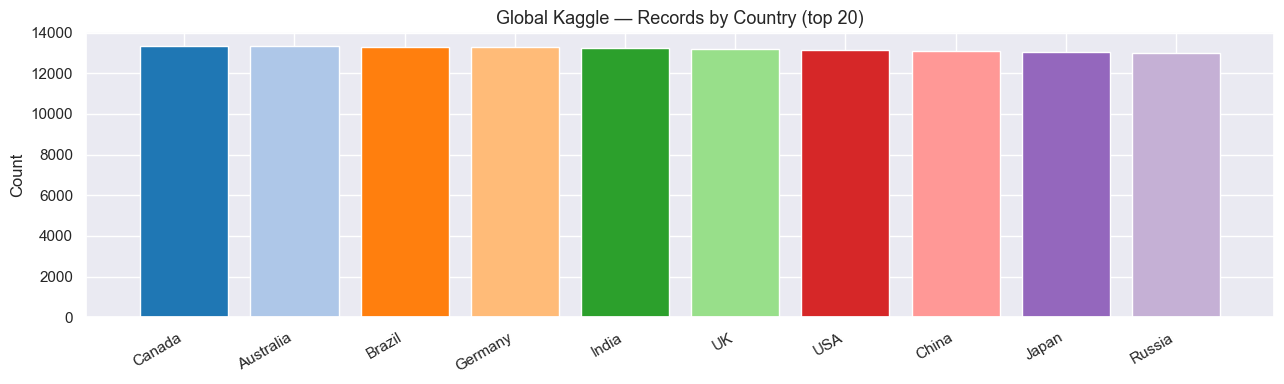

India rows present: 13,238


In [27]:
# Country distribution
country_vc = df_global["Country"].value_counts()
plt.figure(figsize=(13, 4))
plt.bar(country_vc.index[:20], country_vc.values[:20],
        color=sns.color_palette("tab20"))
plt.title("Global Kaggle — Records by Country (top 20)", fontsize=13)
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PROCESSED / "eda_global_countries.png", dpi=120)
plt.show()
print(f"India rows present: {(df_global['Country']=='India').sum():,}")

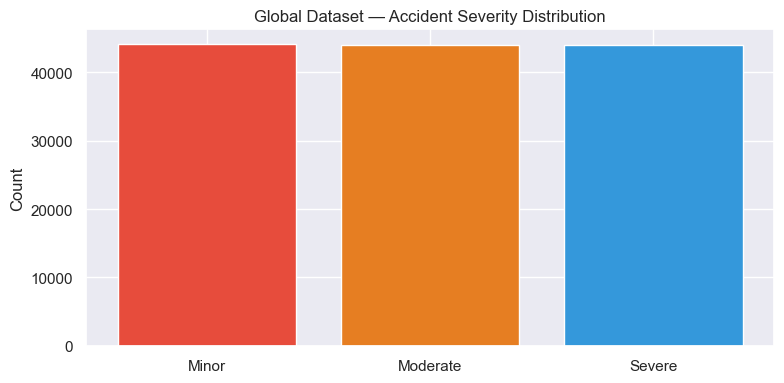

Severity values: ['Minor', 'Moderate', 'Severe']


In [28]:
# Severity distribution (Accident Severity column)
sev_vc = df_global["Accident Severity"].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(sev_vc.index, sev_vc.values,
        color=["#e74c3c","#e67e22","#3498db","#2ecc71"])
plt.title("Global Dataset — Accident Severity Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PROCESSED / "eda_global_severity.png", dpi=120)
plt.show()
print("Severity values:", list(sev_vc.index))

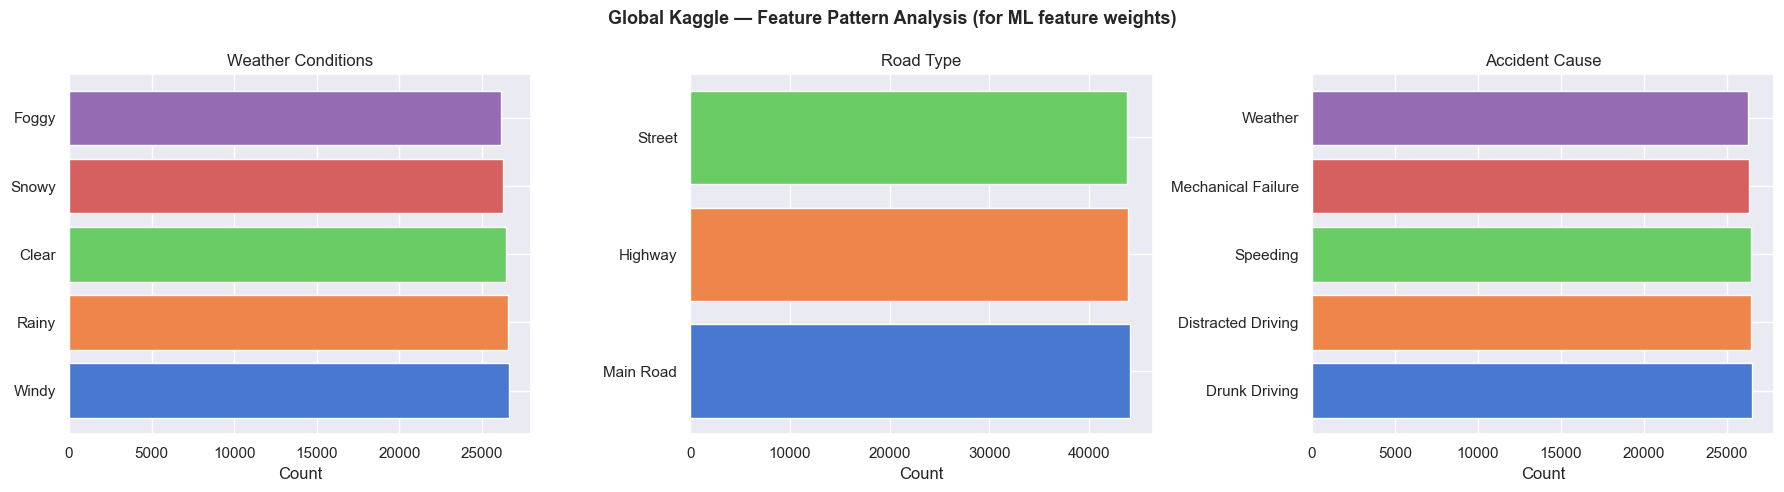

In [29]:
# Weather and Road Type from Global (important for feature weights)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Global Kaggle — Feature Pattern Analysis (for ML feature weights)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["Weather Conditions","Road Type","Accident Cause"]):
    if col in df_global.columns:
        vc = df_global[col].value_counts().head(8)
        ax.barh(vc.index, vc.values, color=sns.color_palette("muted", len(vc)))
        ax.set_title(col)
        ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(PROCESSED / "eda_global_features.png", dpi=120)
plt.show()

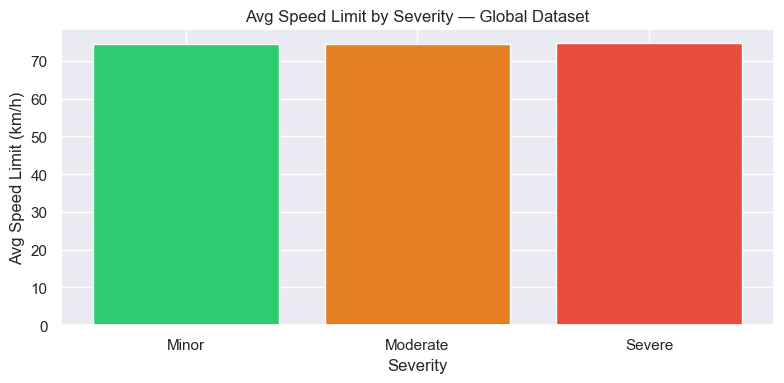

Speed limit vs severity insight:
Accident Severity
Minor      74.50
Moderate   74.50
Severe     74.60


In [30]:
# Speed limit vs severity — key insight for risk scoring
if "Speed Limit" in df_global.columns and "Accident Severity" in df_global.columns:
    sev_map_g = {"Minor": 1, "Moderate": 2, "Severe": 3, "Fatal": 4}
    df_global["severity_num"] = df_global["Accident Severity"].map(sev_map_g)

    speed_sev = df_global.groupby("Accident Severity")["Speed Limit"].mean()
    plt.figure(figsize=(8, 4))
    plt.bar(speed_sev.index, speed_sev.values,
            color=["#2ecc71","#e67e22","#e74c3c","#8e44ad"])
    plt.title("Avg Speed Limit by Severity — Global Dataset", fontsize=12)
    plt.ylabel("Avg Speed Limit (km/h)")
    plt.xlabel("Severity")
    plt.tight_layout()
    plt.savefig(PROCESSED / "eda_global_speed_severity.png", dpi=120)
    plt.show()
    print("Speed limit vs severity insight:")
    print(speed_sev.round(1).to_string())

### MoRTH Official Government Data

In [31]:
def clean_morth_numeric(df):
    for col in df.columns:
        if df[col].dtype == object:
            cleaned = df[col].astype(str).str.replace(",","").str.strip()
            numeric = pd.to_numeric(cleaned, errors="coerce")
            if numeric.notna().sum() > len(df) * 0.5:
                df[col] = numeric
    return df

df_sw_acc  = clean_morth_numeric(df_sw_acc)
df_sw_fat  = clean_morth_numeric(df_sw_fat)
df_collide = clean_morth_numeric(df_collide)
df_violate = clean_morth_numeric(df_violate)
df_cities  = clean_morth_numeric(df_cities)
print(" MoRTH numeric columns cleaned")

 MoRTH numeric columns cleaned


In [ ]:
# State column name
state_col = [c for c in df_sw_acc.columns if "state" in c.lower() or "State" in c][0]
acc_2023_col = [c for c in df_sw_acc.columns if "2023" in str(c) and "Accident" in str(c)]
acc_2023_col = acc_2023_col[0] if acc_2023_col else None

print(f"State column  : '{state_col}'")
print(f"2023 Acc col  : '{acc_2023_col}'")
print()
print("Top 10 states by accidents (2023):")

## Fixing the type error
df_sw_acc[acc_2023_col] = (
    df_sw_acc[acc_2023_col]
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_sw_acc[acc_2023_col] = pd.to_numeric(df_sw_acc[acc_2023_col], errors='coerce')
print(df_sw_acc[acc_2023_col].dtype)
## fixing the type error
if acc_2023_col:
    top10 = df_sw_acc.dropna(subset=[acc_2023_col]).nlargest(10, acc_2023_col)
    print(top10[[state_col, acc_2023_col]].to_string(index=False))

State column  : 'State'
2023 Acc col  : '2023 Accidents'

Top 10 states by accidents (2023):
float64
         State  2023 Accidents
     All India       480583.00
    Tamil Nadu        67213.00
Madhya Pradesh        55327.00
        Kerala        48091.00
 Uttar Pradesh        44534.00
     Karnataka        43440.00
   Maharashtra        35243.00
     Rajasthan        24694.00
     Telangana        22903.00
Andhra Pradesh        19949.00


In [35]:
# Violation types — THE KEY INSIGHT
print("VIOLATION TYPES 2023 (over-speeding dominates):")
print(df_violate.to_string())

VIOLATION TYPES 2023 (over-speeding dominates):
                                         Category 2022-Accidents 2022-Killed 2022-injured 2023-Accidents 2023-Killed 2023-injured  %Change-Accidents  %Change-killed  %Change-Injured
0                                   Over-speeding       3,33,323    1,19,904     3,22,795       3,28,727    1,17,682     3,20,416              -1.38           -1.85            -0.74
1                                % share of total          72.26       71.16        72.81           68.4       68.07        69.23                NaN             NaN              NaN
2   Drunken driving/consumption of alcohol & drug         10,080       4,201        8,809          9,143       3,674        8,421              -9.30          -12.54            -4.40
3                                % share of total           2.19        2.49         1.99            1.9        2.13         1.82                NaN             NaN              NaN
4         Driving on wrong side/Lane indis

In [36]:
# Collision types
print("COLLISION TYPES 2023:")
print(df_collide.to_string())

COLLISION TYPES 2023:
      Type of collision 2022-Accidents 2022-Killed 2022-injured 2023-Accidents 2023-Killed 2023-injured  %Change-Accidents  %Change-killed  %Change-Injured
0           Hit and Run         67,387      30,486       54,726         68,783      31,209       54,574               2.10            2.40            -0.30
1               % share             15          18           12             14          18           12                NaN             NaN              NaN
2   With parked Vehicle         14,139       6,012       12,666         13,810       5,636       12,575              -2.30           -6.30            -0.70
3               % share              3           4            3              3           3            3                NaN             NaN              NaN
4         Hit from Back         98,668      32,907       95,241       1,10,656      36,804     1,07,161              12.10           11.80            12.50
5               % share             21    

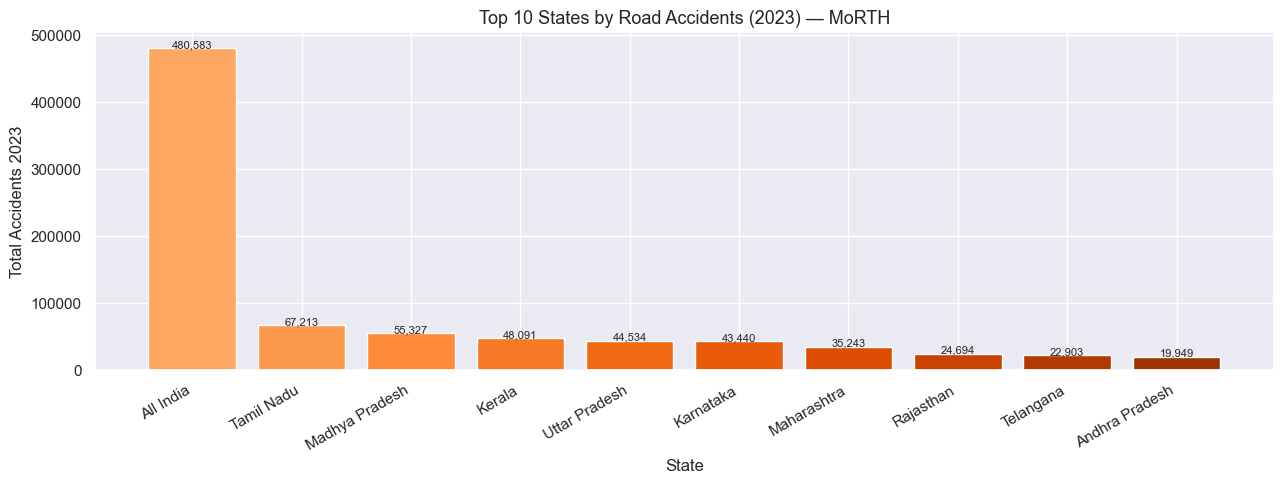

In [37]:
# Top states viz
if acc_2023_col:
    top10 = df_sw_acc.dropna(subset=[acc_2023_col]).nlargest(10, acc_2023_col)
    plt.figure(figsize=(13, 5))
    bars = plt.bar(top10[state_col].astype(str), top10[acc_2023_col],
                   color=plt.cm.Oranges(np.linspace(0.4, 0.9, 10)))
    plt.title("Top 10 States by Road Accidents (2023) — MoRTH", fontsize=13)
    plt.xlabel("State")
    plt.ylabel("Total Accidents 2023")
    plt.xticks(rotation=30, ha="right")
    for bar, val in zip(bars, top10[acc_2023_col]):
        if pd.notna(val):
            plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                     f"{int(val):,}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig(PROCESSED / "eda_morth_top_states.png", dpi=120)
    plt.show()

In [38]:
# Punjab specifically
print("Punjab in MoRTH data:")
punjab_acc = df_sw_acc[df_sw_acc[state_col].str.contains("Punjab", case=False, na=False)]
punjab_fat = df_sw_fat[df_sw_fat[[c for c in df_sw_fat.columns
                                   if "state" in c.lower()][0]]
                       .str.contains("Punjab", case=False, na=False)]
print("Accidents:")
print(punjab_acc.to_string(index=False))
print("\nFatalities:")
print(punjab_fat.to_string(index=False))

Punjab in MoRTH data:
Accidents:
Sl No  State 2019 Accidents 2020 Accidents 2021 Accidents 2022 Accidents  2023 Accidents Change from 2022 to 2023  % change from 2022 to 2023 2019 Ranking  2020 Ranking  2021 Ranking  2022 Ranking  2023 Ranking
   20 Punjab           6348           5203           5871           6138         6269.00                      131                        2.10           17         17.00         17.00         17.00         18.00

Fatalities:
Sl No  State 2019 Killed 2020 Killed 2021 Killed 2022 Killed 2023 Killed  % change from 2022 to 2023  2019 Ranking  2020 Ranking  2021 Ranking  2022 Ranking  2023 Ranking
   20 Punjab       4,525       3,898       4,589       4,756       4,829                        1.50         15.00         15.00         15.00         15.00         15.00


### Spatial OverView - only valid gps data (mendeley)

In [39]:
# Only Mendeley has real GPS — plot it
try:
    import folium
    from folium.plugins import HeatMap

    spatial = df_mendeley[["latitude","longitude","Killed"]].dropna()
    spatial = spatial[spatial["latitude"].between(6,38) &
                      spatial["longitude"].between(65,98)]

    m = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
                   tiles="CartoDB positron")

    heat_data = [[r["latitude"], r["longitude"], float(r["Killed"])+1]
                 for _, r in spatial.iterrows()]
    HeatMap(heat_data, radius=14, blur=18, max_zoom=12).add_to(m)

    # Mark top-killed crash points
    top_crashes = spatial.nlargest(20, "Killed")
    for _, r in top_crashes.iterrows():
        folium.CircleMarker(
            [r["latitude"], r["longitude"]],
            radius=6, color="#e74c3c", fill=True, fill_opacity=0.9,
            popup=f"Killed: {int(r['Killed'])}"
        ).add_to(m)

    map_path = str(PROCESSED / "eda_mendeley_heatmap.html")
    m.save(map_path)
    print(f"✅ Interactive heatmap saved → {map_path}")
    print(f"   {len(spatial):,} crash points plotted")
    print("   Open this HTML file in your browser!")

except ImportError:
    print("folium not installed — matplotlib fallback:")
    spatial = df_mendeley[["latitude","longitude","Killed"]].dropna()
    fig, ax = plt.subplots(figsize=(10, 12))
    sc = ax.scatter(spatial["longitude"], spatial["latitude"],
                    c=spatial["Killed"], cmap="Reds",
                    s=40, alpha=0.7, edgecolors="none")
    plt.colorbar(sc, label="Killed")
    ax.set_title("India Fatal Crash Locations — Mendeley Dataset", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(65, 98)
    ax.set_ylim(6, 38)
    plt.tight_layout()
    plt.savefig(PROCESSED / "eda_spatial_scatter.png", dpi=130)
    plt.show()

✅ Interactive heatmap saved → ..\data\processed\eda_mendeley_heatmap.html
   2,898 crash points plotted
   Open this HTML file in your browser!


###  EDA Summary

In [42]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    EDA KEY FINDINGS                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  SPATIAL DATA (what we can cluster)                              ║
║  • Mendeley:     2,900 real GPS crashes → PRIMARY for DBSCAN     ║
║  • Kaggle India: 3,000 rows → geocoded via city/state lookup     ║
║  • Global:       NO coords → feature patterns only               ║
║                                                                  ║
║  SEVERITY DRIVERS (from MoRTH 2023 official data)               ║
║  • Over-speeding     = 68.4% of all India accidents              ║
║  • Hit from back     = 23% of all collisions                     ║
║  • Head-on collision = 18% of all collisions                     ║
║  • Drunken driving   = 1.9% but 2.1% of fatalities               ║
║                                                                  ║
║  TIME PATTERNS (Kaggle India)                                    ║
║  • Peak accident hours: Evening (17:00–20:00)                    ║
║  • Night hours (20:00–05:00) → higher severity                   ║
║  • Monsoon months (Jul–Oct) → higher accident counts             ║
║                                                                  ║
║  ROAD & VEHICLE PATTERNS (Mendeley India)                        ║
║  • NH (National Highway) dominates fatal crashes                 ║
║  • Head-on + Hit & Run most lethal crash types                   ║
║  • Two-wheelers and cars most involved vehicle types             ║
║                                                                  ║
║  GLOBAL PATTERNS (for feature weight calibration)                ║
║  • Higher speed limit → higher severity (confirmed)              ║
║  • Foggy weather → high severity across all countries            ║
║  • Highway crashes → higher fatality rate than streets           ║
║                                                                  ║
║                                 ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║                    EDA KEY FINDINGS                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  SPATIAL DATA (what we can cluster)                              ║
║  • Mendeley:     2,900 real GPS crashes → PRIMARY for DBSCAN     ║
║  • Kaggle India: 3,000 rows → geocoded via city/state lookup     ║
║  • Global:       NO coords → feature patterns only               ║
║                                                                  ║
║  SEVERITY DRIVERS (from MoRTH 2023 official data)               ║
║  • Over-speeding     = 68.4% of all India accidents              ║
║  • Hit from back     = 23% of all collisions                     ║
║  • Head-on collision = 18% of all collisions                     ║
║  • Drunken driving   = 1.9% but 2.1% of fatalities               ║
║                                 